## 1. Install Dependencies

In [1]:
!pip install ultralytics -q
!pip install opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.3 MB/s eta 0:00:00a 0:00:01


## 2. Imports & Configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2595.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P0524.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P1651.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2242.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2789.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P1128.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P1179.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P1742.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2135.png
/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA/val/images/P2420.png
/kaggle/input/datasets/divyadharshinis22

In [4]:
import os
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import cv2
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_INPUT  = Path('/kaggle/input/datasets/divyadharshinis22/dotadataset-with-annotations/DOTA')
BASE_OUTPUT = Path('/kaggle/working/dota_yolo')

TRAIN_IMGS  = BASE_INPUT / 'train' / 'images'
TRAIN_LBLS  = BASE_INPUT / 'train' / 'labelTxt'
VAL_IMGS    = BASE_INPUT / 'val'   / 'images'
VAL_LBLS    = BASE_INPUT / 'val'   / 'labelTxt'
TEST_IMGS   = BASE_INPUT / 'test'  / 'images'

# ── DOTA v1.0 class list (order matters – index = class id) ───────────────
DOTA_CLASSES = [
    'plane', 'ship', 'storage-tank', 'baseball-diamond',
    'tennis-court', 'basketball-court', 'ground-track-field',
    'harbor', 'bridge', 'large-vehicle', 'small-vehicle',
    'helicopter', 'roundabout', 'soccer-ball-field', 'swimming-pool'
]
CLASS2ID = {c: i for i, c in enumerate(DOTA_CLASSES)}

print('Classes:', DOTA_CLASSES)
print('Train images :', len(list(TRAIN_IMGS.glob('*.png'))))
print('Val   images :', len(list(VAL_IMGS.glob('*.png'))))
print('Test  images :', len(list(TEST_IMGS.glob('*.png'))))

Classes: ['plane', 'ship', 'storage-tank', 'baseball-diamond', 'tennis-court', 'basketball-court', 'ground-track-field', 'harbor', 'bridge', 'large-vehicle', 'small-vehicle', 'helicopter', 'roundabout', 'soccer-ball-field', 'swimming-pool']
Train images : 1411
Val   images : 458
Test  images : 937


## 3. DOTA → YOLO Label Conversion

In [5]:
def parse_dota_label(label_path: Path):
    """Parse a DOTA labelTxt file and return list of (class_name, x1,y1,x2,y2,x3,y3,x4,y4)."""
    instances = []
    with open(label_path, 'r') as f:
        for line in f:
            line = line.strip()
            # Skip metadata header lines
            if not line or line.startswith('imagesource') or line.startswith('gsd') or line.startswith('acquisition'):
                continue
            parts = line.split()
            if len(parts) < 10:
                continue
            coords = list(map(float, parts[:8]))   # x1 y1 x2 y2 x3 y3 x4 y4
            category  = parts[8].lower().replace(' ', '-')
            # difficult = int(parts[9])  # 0 or 1
            instances.append((category, coords))
    return instances


def obb_to_hbb_yolo(coords, img_w, img_h):
    """Convert OBB [x1,y1,...,x4,y4] to normalised YOLO [cx, cy, w, h]."""
    xs = coords[0::2]   # x1 x2 x3 x4
    ys = coords[1::2]   # y1 y2 y3 y4
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    cx = (x_min + x_max) / 2 / img_w
    cy = (y_min + y_max) / 2 / img_h
    w  = (x_max - x_min) / img_w
    h  = (y_max - y_min) / img_h
    # Clamp to [0, 1]
    cx = max(0.0, min(1.0, cx))
    cy = max(0.0, min(1.0, cy))
    w  = max(0.0, min(1.0, w))
    h  = max(0.0, min(1.0, h))
    return cx, cy, w, h


def convert_split(img_dir: Path, lbl_dir: Path, out_img_dir: Path, out_lbl_dir: Path,
                  class2id: dict, symlink_images: bool = True):
    """Convert all images+labels in a split to YOLO format."""
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    skipped, converted = 0, 0
    img_files = sorted(img_dir.glob('*.png'))

    for img_path in tqdm(img_files, desc=f'Converting {img_dir.parent.name}'):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists():
            skipped += 1
            continue

        # Get image dimensions without loading full image
        img = Image.open(img_path)
        img_w, img_h = img.size
        img.close()

        instances = parse_dota_label(lbl_path)
        yolo_lines = []
        for cat, coords in instances:
            if cat not in class2id:
                continue   # skip unknown categories
            cls_id = class2id[cat]
            cx, cy, w, h = obb_to_hbb_yolo(coords, img_w, img_h)
            yolo_lines.append(f'{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}')

        # Write YOLO label file
        out_lbl = out_lbl_dir / (img_path.stem + '.txt')
        with open(out_lbl, 'w') as f:
            f.write('\n'.join(yolo_lines))

        # Symlink or copy image
        out_img = out_img_dir / img_path.name
        if not out_img.exists():
            if symlink_images:
                out_img.symlink_to(img_path.resolve())
            else:
                shutil.copy2(img_path, out_img)
        converted += 1

    print(f'  → converted: {converted}  |  skipped (no label): {skipped}')


# Run conversions
convert_split(TRAIN_IMGS, TRAIN_LBLS,
              BASE_OUTPUT/'images/train', BASE_OUTPUT/'labels/train',
              CLASS2ID)

convert_split(VAL_IMGS, VAL_LBLS,
              BASE_OUTPUT/'images/val', BASE_OUTPUT/'labels/val',
              CLASS2ID)

# Test set – no labels, just symlink images for inference later
(BASE_OUTPUT/'images/test').mkdir(parents=True, exist_ok=True)
for img_path in tqdm(sorted(TEST_IMGS.glob('*.png')), desc='Linking test images'):
    out_img = BASE_OUTPUT / 'images/test' / img_path.name
    if not out_img.exists():
        out_img.symlink_to(img_path.resolve())

print('\nDataset structure ready at:', BASE_OUTPUT)

Converting train: 100%|██████████| 1411/1411 [00:14<00:00, 99.87it/s] 


  → converted: 1411  |  skipped (no label): 0


Converting val: 100%|██████████| 458/458 [00:04<00:00, 107.28it/s]


  → converted: 458  |  skipped (no label): 0


Linking test images: 100%|██████████| 937/937 [00:00<00:00, 1634.84it/s]


Dataset structure ready at: /kaggle/working/dota_yolo


## 4. Write dataset.yaml

In [6]:
dataset_yaml = {
    'path'  : str(BASE_OUTPUT),
    'train' : 'images/train',
    'val'   : 'images/val',
    'test'  : 'images/test',
    'nc'    : len(DOTA_CLASSES),
    'names' : DOTA_CLASSES
}

yaml_path = BASE_OUTPUT / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)

print('dataset.yaml written:')
print(open(yaml_path).read())

dataset.yaml written:
path: /kaggle/working/dota_yolo
train: images/train
val: images/val
test: images/test
nc: 15
names:
- plane
- ship
- storage-tank
- baseball-diamond
- tennis-court
- basketball-court
- ground-track-field
- harbor
- bridge
- large-vehicle
- small-vehicle
- helicopter
- roundabout
- soccer-ball-field
- swimming-pool



## 5. Visualise a Few Training Samples

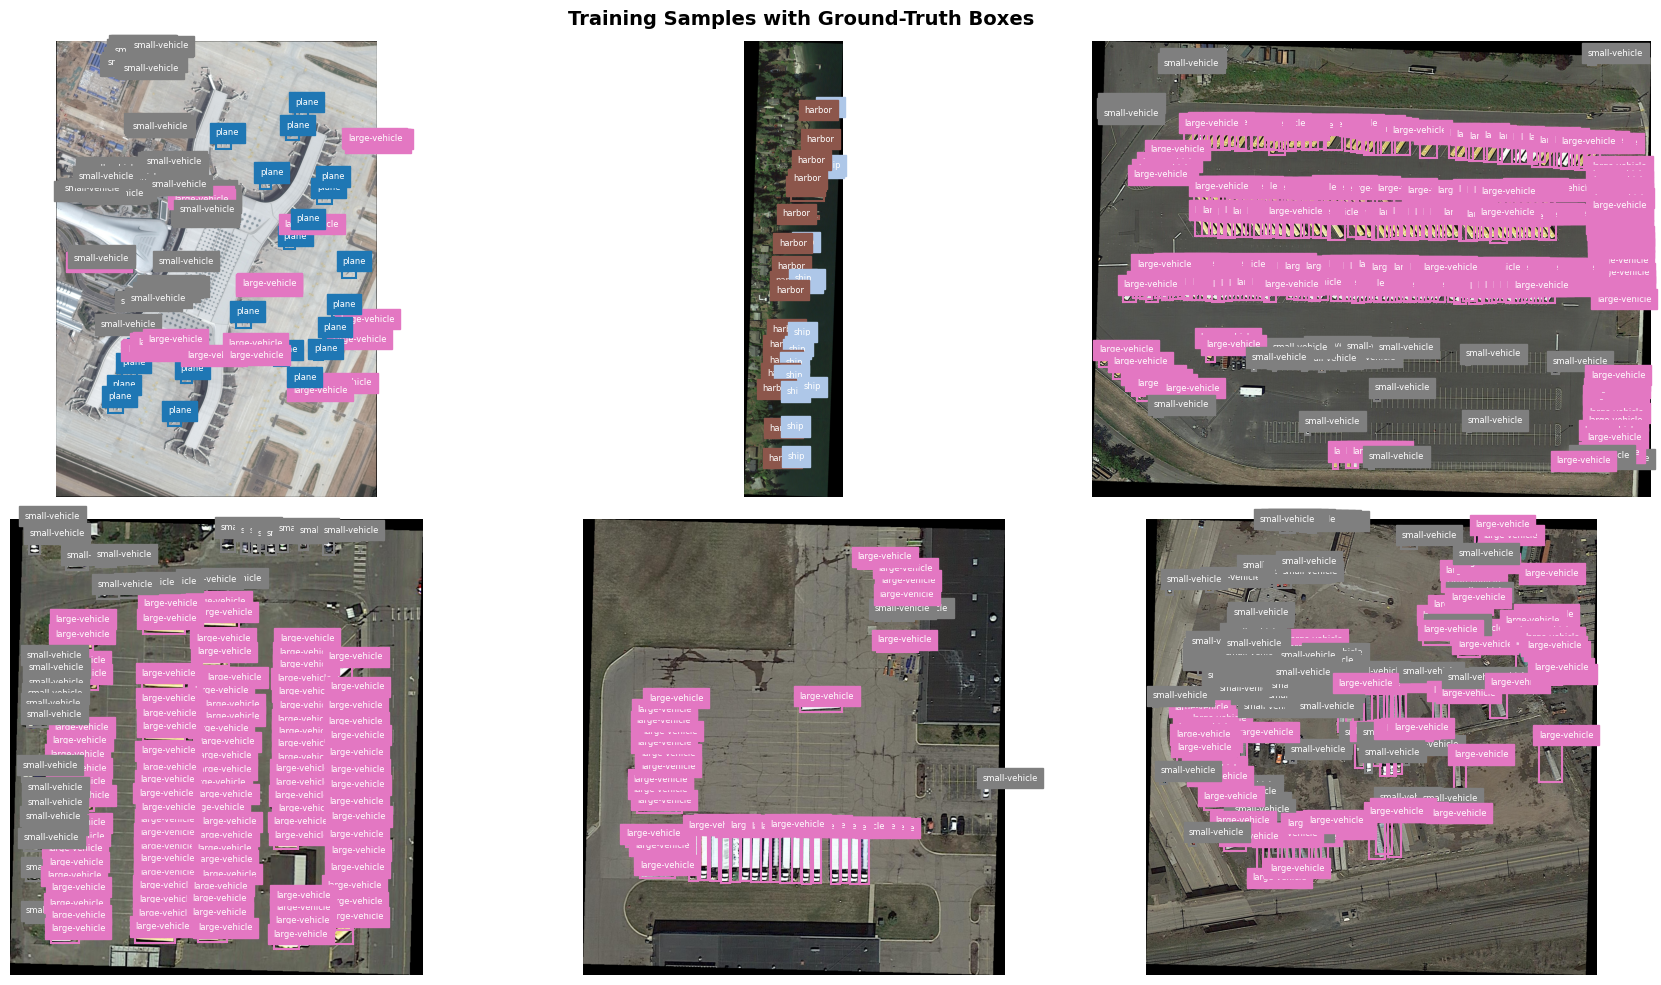

In [7]:
COLORS = matplotlib.colormaps.get_cmap('tab20').resampled(len(DOTA_CLASSES))

def show_yolo_sample(img_path, lbl_path, class_names, ax):
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]
    ax.imshow(img)
    if lbl_path.exists():
        for line in open(lbl_path).read().strip().split('\n'):
            if not line:
                continue
            parts = list(map(float, line.split()))
            cls_id = int(parts[0])
            cx, cy, bw, bh = parts[1:]
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                      linewidth=1.5, edgecolor=COLORS(cls_id),
                                      facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-3, class_names[cls_id], fontsize=6,
                    color='white', backgroundcolor=COLORS(cls_id))
    ax.axis('off')

img_files = sorted((BASE_OUTPUT/'images/train').glob('*.png'))[:6]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, img_path in zip(axes.flatten(), img_files):
    lbl_path = BASE_OUTPUT / 'labels/train' / (img_path.stem + '.txt')
    show_yolo_sample(img_path, lbl_path, DOTA_CLASSES, ax)
plt.suptitle('Training Samples with Ground-Truth Boxes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/train_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Class Distribution Analysis

             Class  Train  Val
             plane   8055 2531
              ship  28068 8960
      storage-tank   5029 2888
  baseball-diamond    415  214
      tennis-court   2367  760
  basketball-court    515  132
ground-track-field    325  144
            harbor   5983 2090
            bridge   2047  464
     large-vehicle  16969 4387
     small-vehicle  26126 5438
        helicopter    630   73
        roundabout    399  179
 soccer-ball-field    326  153
     swimming-pool   1736  440


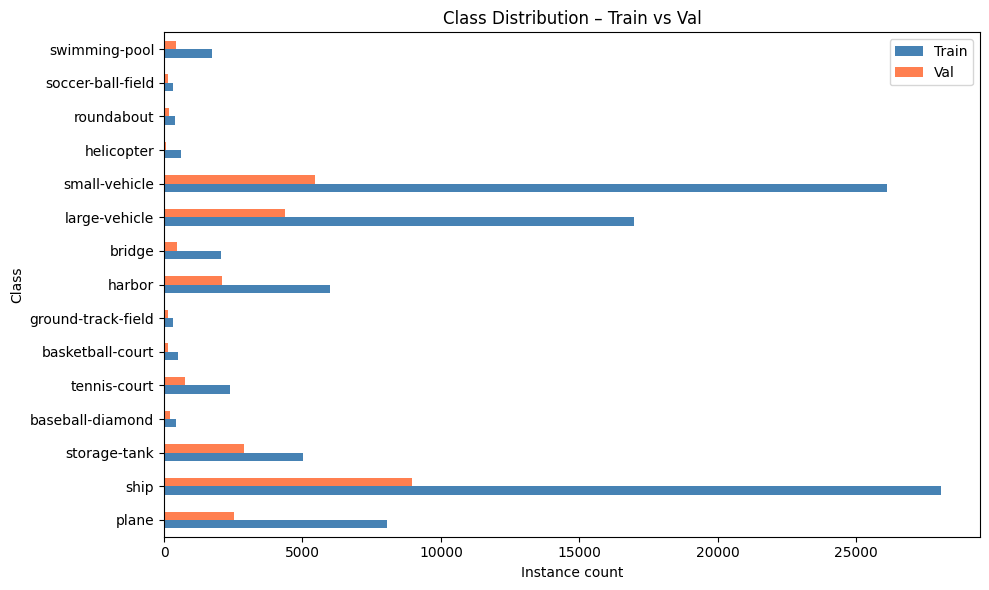

In [9]:
from collections import Counter

def count_classes(lbl_dir: Path, nc: int):
    counts = Counter()
    for f in lbl_dir.glob('*.txt'):
        for line in open(f).read().strip().split('\n'):
            if line:
                counts[int(line.split()[0])] += 1
    return counts

train_counts = count_classes(BASE_OUTPUT/'labels/train', len(DOTA_CLASSES))
val_counts   = count_classes(BASE_OUTPUT/'labels/val',   len(DOTA_CLASSES))

df_dist = pd.DataFrame({
    'Class'  : DOTA_CLASSES,
    'Train'  : [train_counts.get(i, 0) for i in range(len(DOTA_CLASSES))],
    'Val'    : [val_counts.get(i,   0) for i in range(len(DOTA_CLASSES))]
})
print(df_dist.to_string(index=False))

df_dist.set_index('Class').plot(kind='barh', figsize=(10, 6), color=['steelblue','coral'])
plt.xlabel('Instance count')
plt.title('Class Distribution – Train vs Val')
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=120)
plt.show()

## 7. Train YOLOv8

In [10]:
from ultralytics import YOLO

# Load pretrained backbone
model = YOLO('yolov8m.pt')

results = model.train(
    data       = str(yaml_path),
    epochs     = 15,
    imgsz      = 1024,        # DOTA images are large – 1024 captures more detail
    batch      = 4,           # lower if OOM; raise if GPU has headroom
    workers    = 4,
    project    = '/kaggle/working/runs',
    name       = 'dota_yolov8m',
    pretrained = True,
    optimizer  = 'AdamW',
    lr0        = 0.001,
    lrf        = 0.01,
    weight_decay = 0.0005,
    warmup_epochs = 3,
    mosaic     = 1.0,         # mosaic augmentation – great for aerial images
    degrees    = 15.0,        # rotation augmentation for aerial viewpoint
    flipud     = 0.5,         # vertical flip
    fliplr     = 0.5,
    hsv_h      = 0.015,
    hsv_s      = 0.7,
    hsv_v      = 0.4,
    scale      = 0.5,
    patience   = 20,          # early stopping
    save       = True,
    save_period= 10,
    device     = 0,
    amp        = True,        # mixed precision
    verbose    = True,
    seed       = 42
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dota_yolo/dataset.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=

## 8. Validation – mAP Metrics

In [11]:
best_weights = Path('/kaggle/working/runs/dota_yolov8m/weights/best.pt')
model_best = YOLO(str(best_weights))

val_metrics = model_best.val(
    data    = str(yaml_path),
    imgsz   = 1024,
    batch   = 4,
    device  = 0,
    split   = 'val',
    verbose = True
)

print('\n=== Validation Results ===')
print(f'mAP50    : {val_metrics.box.map50:.4f}')
print(f'mAP50-95 : {val_metrics.box.map:.4f}')
print(f'Precision: {val_metrics.box.mp:.4f}')
print(f'Recall   : {val_metrics.box.mr:.4f}')

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,848,445 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2477.6±1083.9 MB/s, size: 3487.1 KB)
val: Scanning /kaggle/working/dota_yolo/labels/val.cache... 458 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 458/458 160.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 115/115 3.4it/s 34.2s0.2s
                   all        458      28853      0.693      0.425      0.442      0.235
                 plane         70       2531      0.852       0.71      0.715      0.404
                  ship        108       8960      0.843      0.565      0.573      0.297
          storage-tank         55       2888      0.924      0.258      0.342      0.177
      baseball-diamond         53        214      0.682      0.304      0.432      0.194
          tennis-court       

## 9. Per-Class AP Table

             Class    AP@50
      tennis-court 0.894690
             plane 0.714870
     large-vehicle 0.705280
            harbor 0.589979
              ship 0.572715
     small-vehicle 0.541610
  basketball-court 0.435221
  baseball-diamond 0.432025
 soccer-ball-field 0.376995
     swimming-pool 0.372849
      storage-tank 0.342051
ground-track-field 0.271618
        roundabout 0.155096
            bridge 0.152974
        helicopter 0.066204


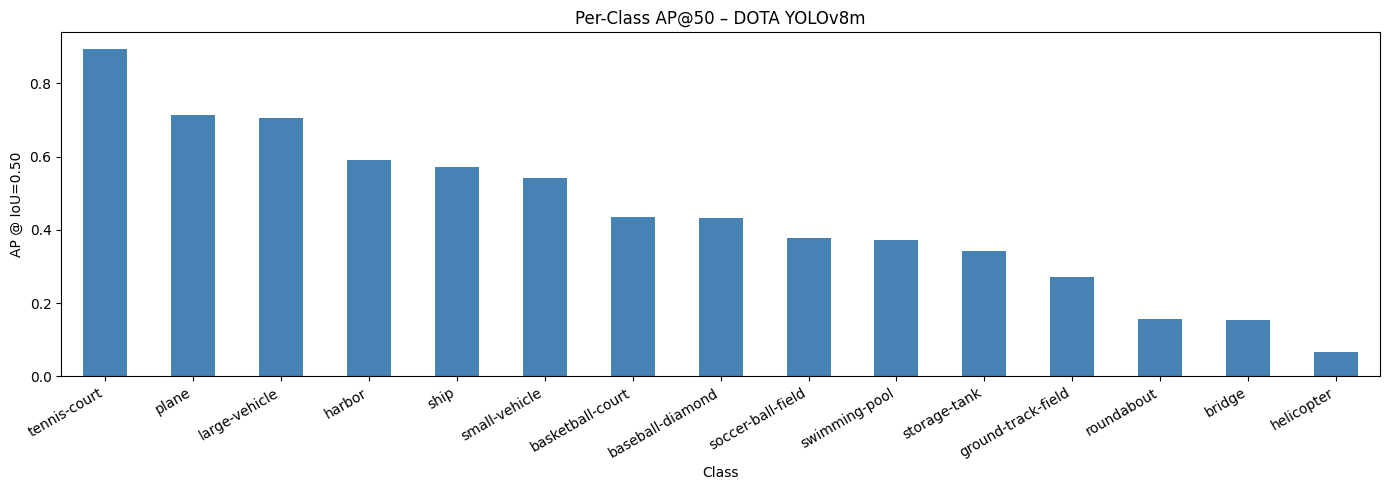

In [12]:
ap_per_class = val_metrics.box.ap50  # array of AP50 per class

df_ap = pd.DataFrame({
    'Class'  : DOTA_CLASSES,
    'AP@50'  : ap_per_class
}).sort_values('AP@50', ascending=False)

print(df_ap.to_string(index=False))

# Bar chart
df_ap.plot(x='Class', y='AP@50', kind='bar', figsize=(14, 5),
           color='steelblue', legend=False)
plt.xticks(rotation=30, ha='right')
plt.ylabel('AP @ IoU=0.50')
plt.title('Per-Class AP@50 – DOTA YOLOv8m')
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_ap.png', dpi=120)
plt.show()

## 10. Training Curves

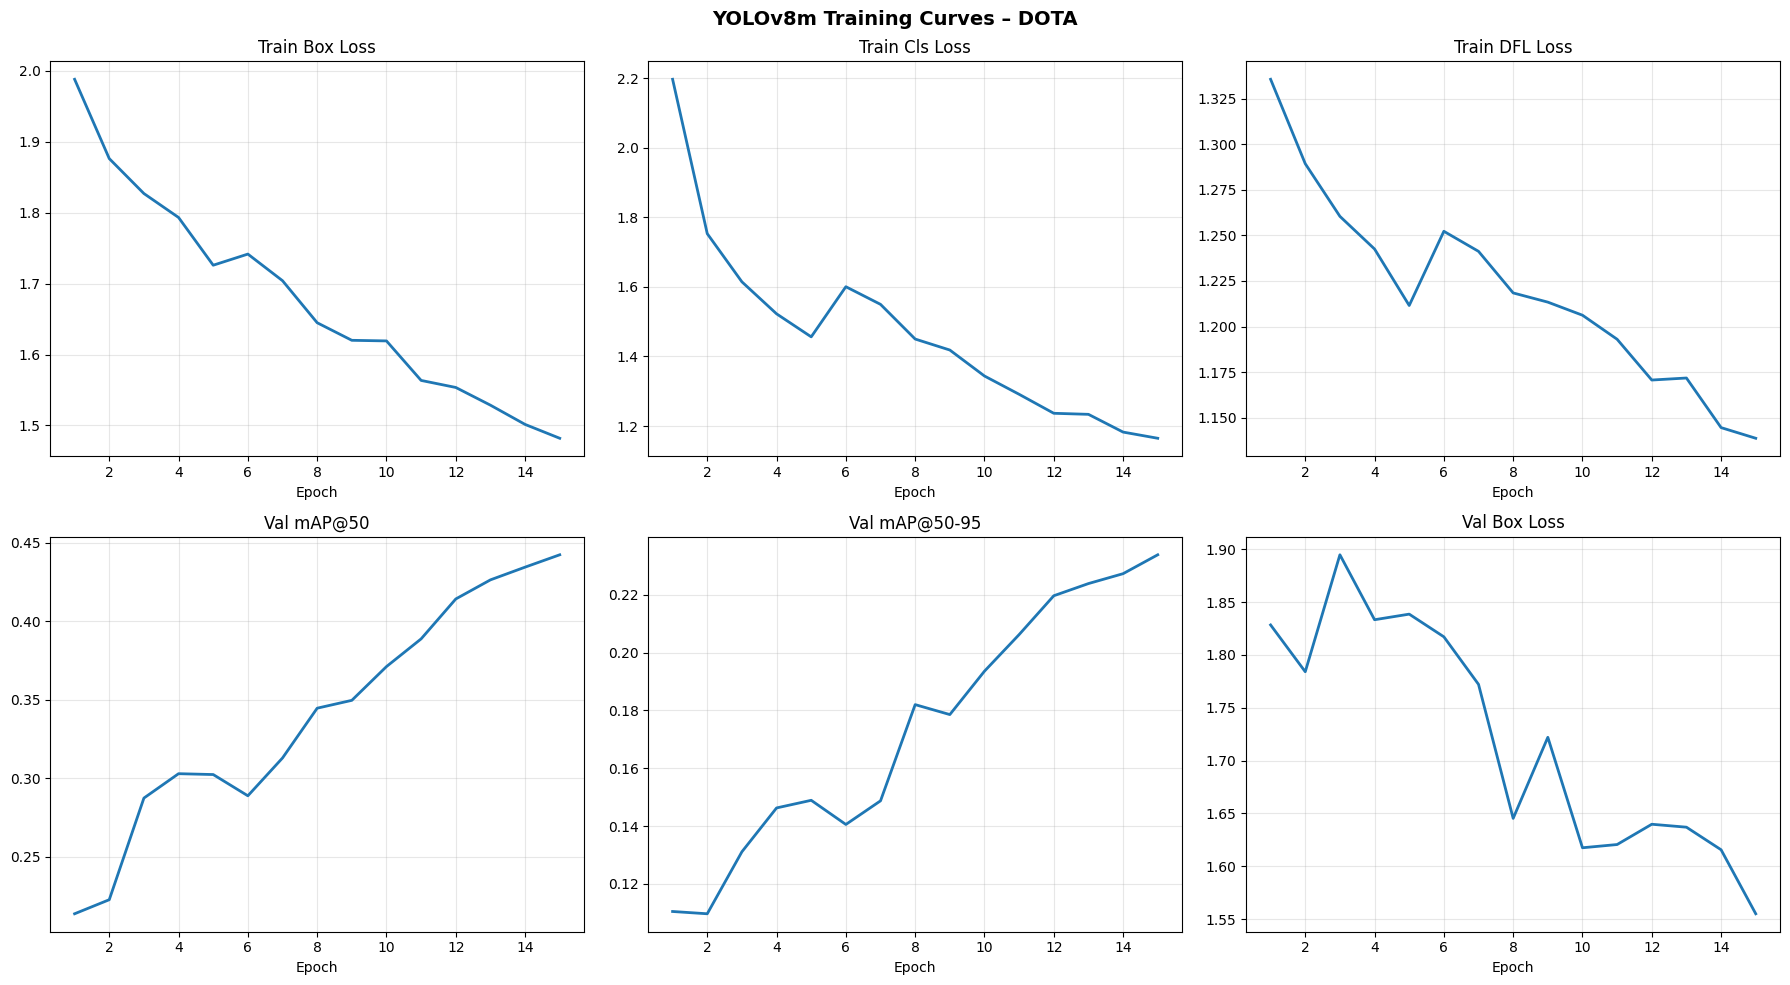

In [13]:
results_csv = Path('/kaggle/working/runs/dota_yolov8m/results.csv')
df_results  = pd.read_csv(results_csv)
df_results.columns = df_results.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_cols = [
    ('train/box_loss',   'Train Box Loss'),
    ('train/cls_loss',   'Train Cls Loss'),
    ('train/dfl_loss',   'Train DFL Loss'),
    ('metrics/mAP50(B)', 'Val mAP@50'),
    ('metrics/mAP50-95(B)', 'Val mAP@50-95'),
    ('val/box_loss',     'Val Box Loss'),
]
for ax, (col, title) in zip(axes.flatten(), plot_cols):
    if col in df_results.columns:
        ax.plot(df_results['epoch'], df_results[col], linewidth=2)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
plt.suptitle('YOLOv8m Training Curves – DOTA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=120)
plt.show()

## 11. Inference on Test Set

In [15]:
from ultralytics import YOLO
import torch

model_predict = YOLO('/kaggle/working/runs/dota_yolov8m/weights/best.pt')

test_preds = model_predict.predict(
    source   = str(BASE_OUTPUT / 'images/test'),
    imgsz    = 1024,
    conf     = 0.2,
    iou      = 0.5,
    device   = 0,
    half     = True,
    save     = True,
    save_txt = True,
    project  = '/kaggle/working/predictions',
    name     = 'test',
    verbose  = False
)
print(f'Predictions saved. Processed {len(test_preds)} images.')

Results saved to /kaggle/working/predictions/test-2
914 labels saved to /kaggle/working/predictions/test-2/labels
Predictions saved. Processed 937 images.


## 12. Visualise Predictions

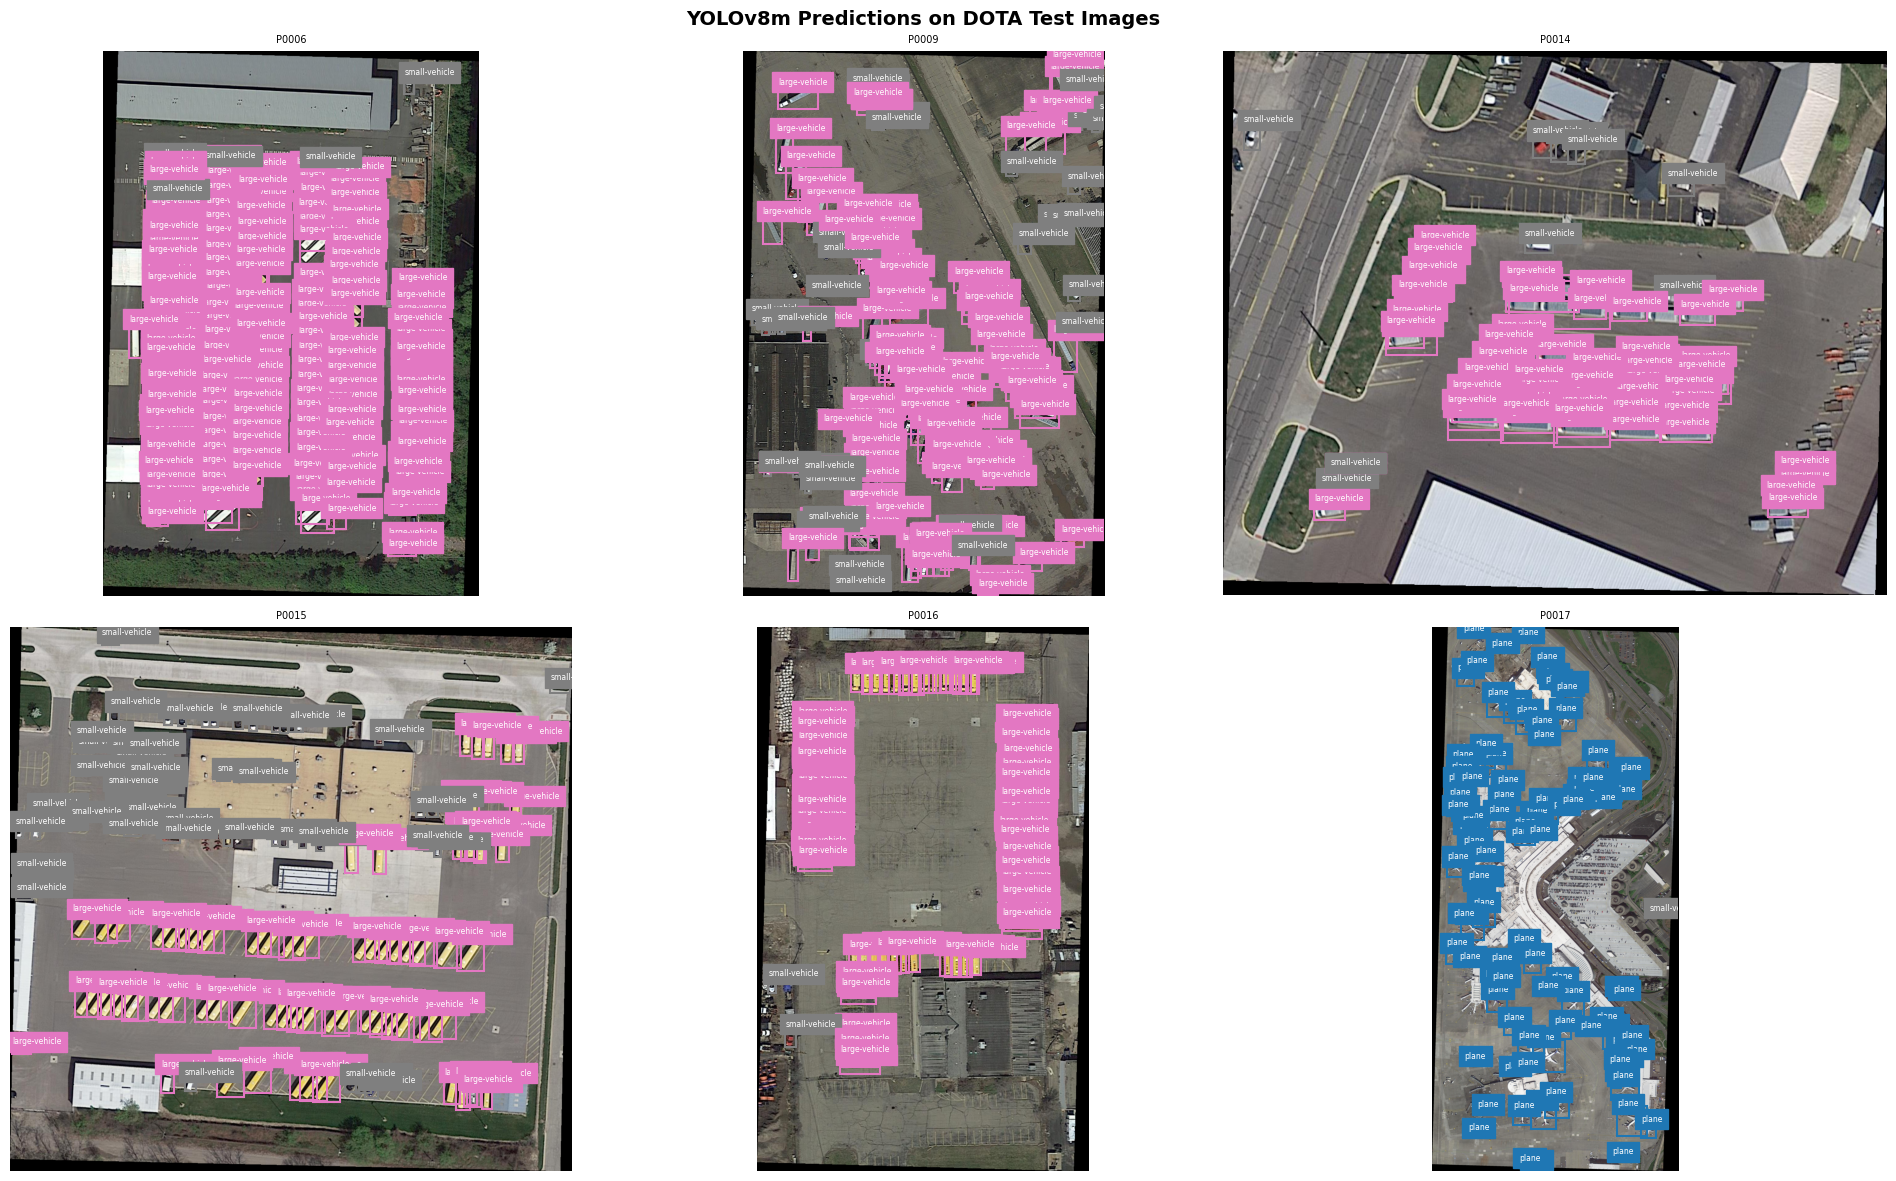

Visualised 6 images with predictions.


In [20]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image

PRED_DIR  = Path('/kaggle/working/predictions/test-2')
LABEL_DIR = PRED_DIR / 'labels'
TEST_IMGS = BASE_OUTPUT / 'images/test'
COLORS = matplotlib.colormaps.get_cmap('tab20').resampled(len(DOTA_CLASSES))

def draw_predictions(img_path, lbl_path, ax):
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]
    ax.imshow(img)

    if lbl_path.exists():
        for line in open(lbl_path).read().strip().split('\n'):
            if not line:
                continue
            parts = line.split()
            cls_id = int(parts[0])
            cx, cy, bw, bh = map(float, parts[1:5])
            conf = float(parts[5]) if len(parts) > 5 else None

            x1 = (cx - bw / 2) * w
            y1 = (cy - bh / 2) * h
            rect = patches.Rectangle(
                (x1, y1), bw * w, bh * h,
                linewidth=1.5,
                edgecolor=COLORS(cls_id),
                facecolor='none'
            )
            ax.add_patch(rect)
            label = f'{DOTA_CLASSES[cls_id]}'
            if conf:
                label += f' {conf:.2f}'
            ax.text(x1, y1 - 3, label,
                    fontsize=5.5, color='white',
                    backgroundcolor=COLORS(cls_id),
                    clip_on=True)
    ax.axis('off')
    ax.set_title(img_path.stem, fontsize=7)

# Pick 6 images that actually have predictions
lbl_files   = sorted(LABEL_DIR.glob('*.txt'))[:6]
img_paths   = [TEST_IMGS / (f.stem + '.png') for f in lbl_files]

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
for ax, img_path, lbl_path in zip(axes.flatten(), img_paths, lbl_files):
    draw_predictions(img_path, lbl_path, ax)

for ax in axes.flatten()[len(lbl_files):]:
    ax.axis('off')

plt.suptitle('YOLOv8m Predictions on DOTA Test Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Visualised {len(lbl_files)} images with predictions.')

## 13. Export Best Model

In [ ]:
# Export to ONNX for deployment
model_best.export(format='onnx', imgsz=1024, dynamic=True, simplify=True)
print('Model exported to ONNX.')

print('\nAll output files:')
for f in sorted(Path('/kaggle/working').rglob('*')):
    if f.is_file() and f.suffix in ('.pt', '.onnx', '.png', '.csv', '.yaml'):
        size_mb = f.stat().st_size / 1e6
        print(f'  {f.relative_to("/kaggle/working")}  ({size_mb:.1f} MB)')